In [ ]:
# To help with reading and manipulation of data
import numpy as np
from numpy import array
import pandas as pd

# To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# To impute missing values
from sklearn.impute import SimpleImputer

# To do one-hot encoding
from sklearn.preprocessing import OneHotEncoder

# To build a decision tree model
from sklearn.tree import DecisionTreeClassifier

# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# To run gridsearch
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
#To install xgboost library use - !pip install xgboost
from xgboost import XGBClassifier
import xgboost
# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [ ]:
Bank_data1 = pd.read_csv('data/bank-additional-full.csv', delimiter=";")
### Creating a copy
data = Bank_data1.copy()
data.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
### Removing Duplicates
data_cl = data.drop_duplicates()

In [ ]:
### Checking Unknown counts on cleaned data
unknown_counts_cl = data_cl.apply(lambda col: (col == "unknown").sum())
print(unknown_counts_cl)

age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [ ]:
### Replacing missing values
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
    data_cl[col] = data_cl[col].replace('unknown', data_cl[col].mode()[0])

In [ ]:
### Checking Unkown values
unknown_counts_cl = data_cl.apply(lambda col: (col == "unknown").sum())
print(unknown_counts_cl)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
for feature in data_cl.columns:
    if data_cl[feature].dtype == 'object': # Only apply for columns with categorical strings
        data_cl[feature] = pd.Categorical(data_cl[feature])# Replace strings with an integer
data_cl.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,university.degree,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
### Data Preparation for modelling

### Drop unnecessary columns and create dummy variables
X = data_cl.drop(columns=['duration','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','pdays','y'])
X = pd.get_dummies(X, drop_first=True)

### Encode 'case_status' as 0 (Denied) and 1 (Certified)
y = data_cl['y'].map({'no': 0, 'yes': 1})


### creating dummy variables
X = pd.get_dummies(X, drop_first=True)

### Ensure boolean columns are converted to 1 and 0
X = X.astype(int)


In [ ]:
# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(32940, 40) (8236, 40) (32940,) (8236,)


In [ ]:
### Checking class balance for whole data, train set, validation set, and test set

print('shape of training set:', X_train.shape)
print('shape of test set:', X_test.shape, '\n')
print('Percentage of clauses in training set:',y_train.value_counts(normalize=True),'\n')
print('Percentage of clauses in test set:',y_test.value_counts(normalize=True))

shape of training set: (32940, 40)
shape of test set: (8236, 40) 

Percentage of clauses in training set: y
0    0.887341
1    0.112659
Name: proportion, dtype: float64 

Percentage of clauses in test set: y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


In [ ]:
###  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)

    # F1 of the model
    train_f1 = metrics.f1_score(y_train,pred_train)
    test_f1 = metrics.f1_score(y_test,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))

    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))
        print("F1 score on training set : ",metrics.f1_score(y_train,pred_train))
        print("F1 score on test set : ",metrics.f1_score(y_test,pred_test))

    return score_list # returning the list with train and test scores

In [ ]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
dtree = DecisionTreeClassifier(random_state=1) ### Using Decision Tree Classifier

### training the decision tree model
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
### Get score
Decision_tree_score = get_metrics_score(dtree)

Accuracy on training set :  0.9914996964177292
Accuracy on test set :  0.8300145701796989
Recall on training set :  0.9256265157639451
Recall on test set :  0.30711206896551724
Precision on training set :  0.9988368711834835
Precision on test set :  0.27351247600767753
F1 score on training set :  0.9608391608391609
F1 score on test set :  0.2893401015228426


In [ ]:
rf_cl = RandomForestClassifier(random_state=1)
rf_cl.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [ ]:
Random_forest_score = get_metrics_score(rf_cl)

Accuracy on training set :  0.9914389799635701
Accuracy on test set :  0.888416707139388
Recall on training set :  0.9366747507410401
Recall on test set :  0.23599137931034483
Precision on training set :  0.9866590973602044
Precision on test set :  0.5104895104895105
F1 score on training set :  0.9610174177495162
F1 score on test set :  0.32277081798084006


In [ ]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(10, 30, 5),
    "min_samples_leaf": [3, 5, 7],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1, cv=5)

grid_obj = grid_obj.fit(X_train, y_train)

dtree_estimator = grid_obj.best_estimator_

dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(10),
                       max_leaf_nodes=3, min_impurity_decrease=0.0001,
                       min_samples_leaf=3, random_state=1)

In [ ]:
### Get score
dtree_estimator_score = get_metrics_score(dtree_estimator)

Accuracy on training set :  0.4403764420157863
Accuracy on test set :  0.44062651772705197
Recall on training set :  0.845863648612234
Recall on test set :  0.8394396551724138
Precision on training set :  0.1494690729012904
Precision on test set :  0.1487492839411877
F1 score on training set :  0.25404661702816445
F1 score on test set :  0.2527169505271695


In [ ]:
### Choosing the best classsifer
rfcls_tuned = RandomForestClassifier(class_weight='balanced',random_state=1)

params = { "n_estimators": np.arange(50, 100, 150),
           'min_samples_split': [3,5,7],
           "max_features": [0.3,0.5,0.7,1],
            "max_samples": np.arange(0.3, 0.7, 0.1),
          }

acc_scr = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(rfcls_tuned, params, scoring=acc_scr,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

rfcls_tuned = grid_obj.best_estimator_
print(rfcls_tuned)


RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       max_samples=np.float64(0.6000000000000001),
                       min_samples_split=7, n_estimators=np.int64(50),
                       random_state=1)


In [ ]:
### Get Score
rfcls_tuned_score = get_metrics_score(rfcls_tuned)

Accuracy on training set :  0.9360352155434123
Accuracy on test set :  0.8859883438562409
Recall on training set :  0.6693613581244947
Recall on test set :  0.3609913793103448
Precision on training set :  0.7384066587395958
Precision on test set :  0.4919236417033774
F1 score on training set :  0.702190812720848
F1 score on test set :  0.41640770665009325


### Smote

In [ ]:
### Fit smote
smote = SMOTE(sampling_strategy= 'auto', k_neighbors=5,random_state=1)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [ ]:
dtree1 = DecisionTreeClassifier(random_state=1) ### Using Decision Tree Classifier

dtree1.fit(X_train_over, y_train_over)

DecisionTreeClassifier(random_state=1)

In [ ]:
### Score
Decision_tree_score_over = get_metrics_score(dtree1)

Accuracy on training set :  0.9867334547662416
Accuracy on test set :  0.804273919378339
Recall on training set :  0.9450282942603072
Recall on test set :  0.35560344827586204
Precision on training set :  0.9377005347593583
Precision on test set :  0.24553571428571427
F1 score on training set :  0.9413501543416991
F1 score on test set :  0.2904929577464789


In [ ]:
rf_cl1 = RandomForestClassifier(random_state=1)
rf_cl1.fit(X_train_over,y_train_over)

RandomForestClassifier(random_state=1)

In [ ]:
Random_forest_score_over = get_metrics_score(rf_cl1)

Accuracy on training set :  0.9853673345476625
Accuracy on test set :  0.851748421563866
Recall on training set :  0.9601185664241444
Recall on test set :  0.39655172413793105
Precision on training set :  0.9142930459327688
Precision on test set :  0.3576287657920311
F1 score on training set :  0.93664563617245
F1 score on test set :  0.3760858456821666


In [ ]:
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

parameters = {
    "max_depth": np.arange(10, 30, 5),
    "min_samples_leaf": [3, 5, 7],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

scorer = metrics.make_scorer(metrics.recall_score) ### Choosing F1 score since it balances precision and recall

grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1)

grid_obj = grid_obj.fit(X_train_over, y_train_over)

dtree_estimator = grid_obj.best_estimator_

dtree_estimator.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(10),
                       max_leaf_nodes=2, min_impurity_decrease=0.0001,
                       min_samples_leaf=3, random_state=1)

In [ ]:
### Get score
dtree_estimator_score = get_metrics_score(dtree_estimator)

Accuracy on training set :  0.897632058287796
Accuracy on test set :  0.896551724137931
Recall on training set :  0.19347884667205606
Recall on test set :  0.1896551724137931
Precision on training set :  0.6545123062898814
Precision on test set :  0.6376811594202898
F1 score on training set :  0.29866888519134777
F1 score on test set :  0.292358803986711


In [ ]:
rfcls_tuned = RandomForestClassifier(class_weight='balanced',random_state=1)

params = { "n_estimators": np.arange(50, 100, 150),
           'min_samples_split': [3,5,7],
           "max_features": [0.3,0.5,0.7,1],
            "max_samples": np.arange(0.3, 0.7, 0.1),
          }

acc_scr = metrics.make_scorer(metrics.f1_score)

grid_obj = GridSearchCV(rfcls_tuned, params, scoring=acc_scr,cv=5,n_jobs=-1) ### Runing grid search to find the best estimator
grid_obj = grid_obj.fit(X_train_over, y_train_over)


rfcls_tuned = grid_obj.best_estimator_
print(rfcls_tuned)

rfcls_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_features=1,
                       max_samples=np.float64(0.6000000000000001),
                       min_samples_split=3, n_estimators=np.int64(50),
                       random_state=1)


RandomForestClassifier(class_weight='balanced', max_features=1,
                       max_samples=np.float64(0.6000000000000001),
                       min_samples_split=3, n_estimators=np.int64(50),
                       random_state=1)

In [ ]:
### Get Score
rfcls_tuned_score = get_metrics_score(rfcls_tuned)

Accuracy on training set :  0.9556769884638737
Accuracy on test set :  0.8899951432734337
Recall on training set :  0.6887631366208569
Recall on test set :  0.21875
Precision on training set :  0.8933939182104159
Precision on test set :  0.5286458333333334
F1 score on training set :  0.7778454047474133
F1 score on test set :  0.3094512195121951


In [ ]:

knn = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 9],
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

knn_score = get_metrics_score(best_knn)

Accuracy on training set :  0.9914996964177292
Accuracy on test set :  0.8771248178727538
Recall on training set :  0.9267043923470762
Recall on test set :  0.20905172413793102
Precision on training set :  0.9976791412822744
Precision on test set :  0.4110169491525424
F1 score on training set :  0.9608829281922324
F1 score on test set :  0.27714285714285714


In [36]:
svm = SVC(kernel='linear', class_weight='balanced', random_state=1)

param_grid = {'C': [0.1, 1, 10]}

grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

svm_score = get_metrics_score(best_svm)

Accuracy on training set :  0.8232544019429265
Accuracy on test set :  0.8210296260320544
Recall on training set :  0.49501482080301806
Recall on test set :  0.49461206896551724
Precision on training set :  0.3175453759723423
Precision on test set :  0.3135245901639344
F1 score on training set :  0.38689974726200504
F1 score on test set :  0.38377926421404684


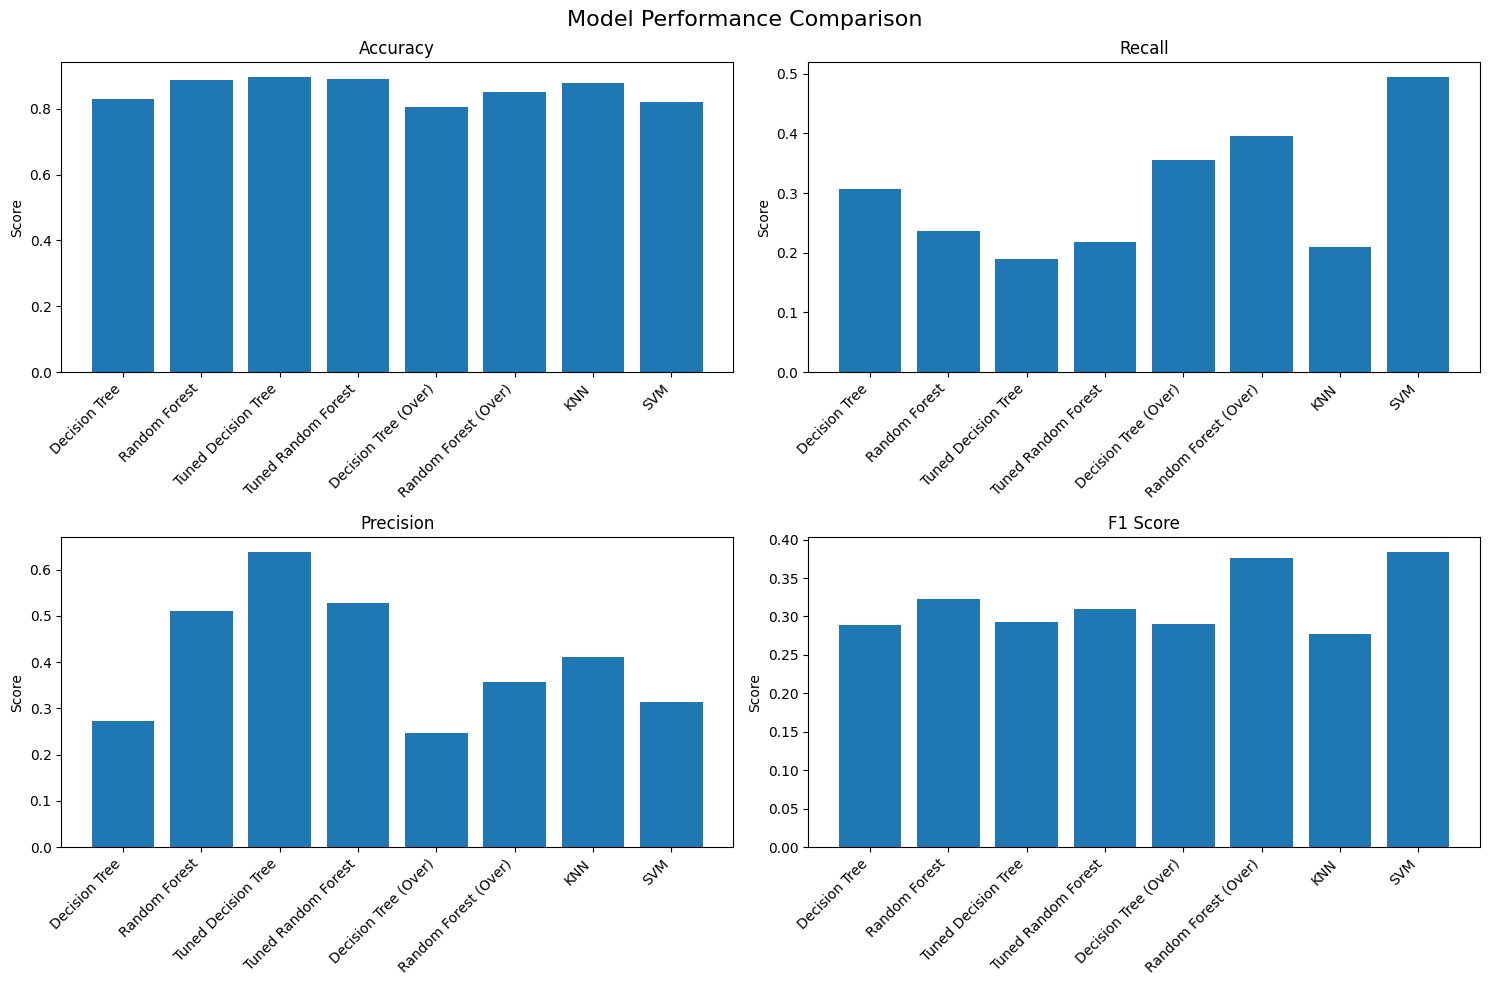

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a list of model names
model_names = ['Decision Tree', 'Random Forest', 'Tuned Decision Tree', 'Tuned Random Forest', 'Decision Tree (Over)', 'Random Forest (Over)', 'KNN', 'SVM']

# Extract Accuracy, Recall, Precision, and F1 scores for each model
accuracy_scores = [score[1] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
recall_scores = [score[3] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
precision_scores = [score[5] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
f1_scores = [score[7] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Accuracy Plot
axes[0, 0].bar(model_names, accuracy_scores)
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')

# Recall Plot
axes[0, 1].bar(model_names, recall_scores)
axes[0, 1].set_title('Recall')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')

# Precision Plot
axes[1, 0].bar(model_names, precision_scores)
axes[1, 0].set_title('Precision')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')

# F1 Score Plot
axes[1, 1].bar(model_names, f1_scores)
axes[1, 1].set_title('F1 Score')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
plt.savefig('model_performance_comparison.png')


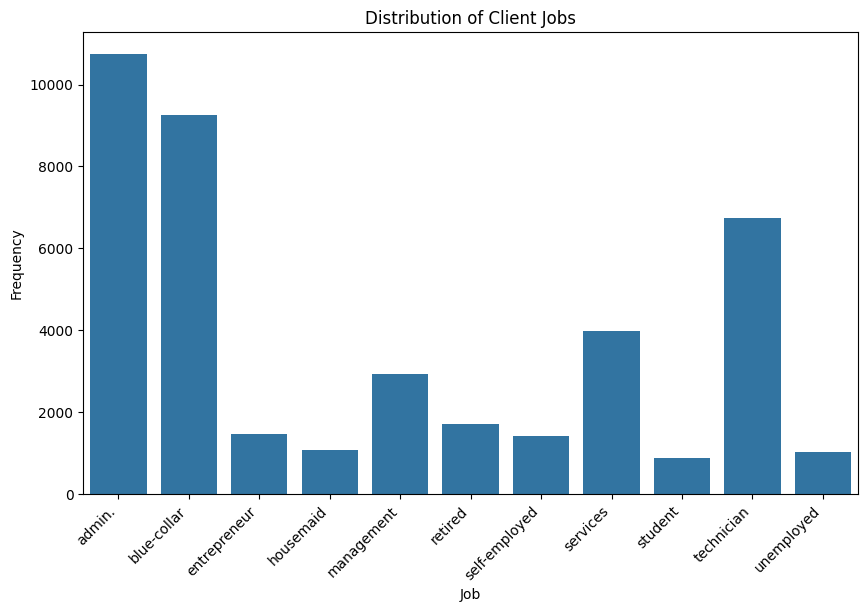

<Figure size 640x480 with 0 Axes>

In [ ]:
# Bar chart for job distribution

plt.figure(figsize=(10, 6))
sns.countplot(x='job', data=data_cl)
plt.title('Distribution of Client Jobs')
plt.xlabel('Job')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()
plt.savefig('job_distribution.png')


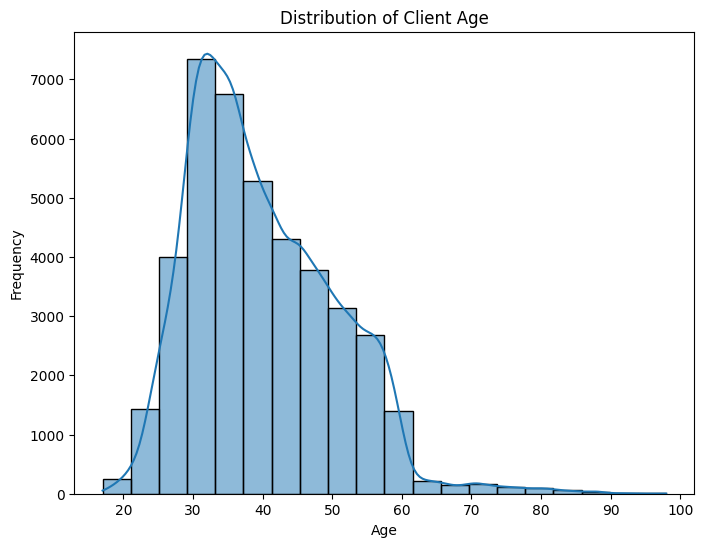

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data_cl['age'], bins=20, kde=True)
plt.title('Distribution of Client Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
plt.savefig('client_age.png')


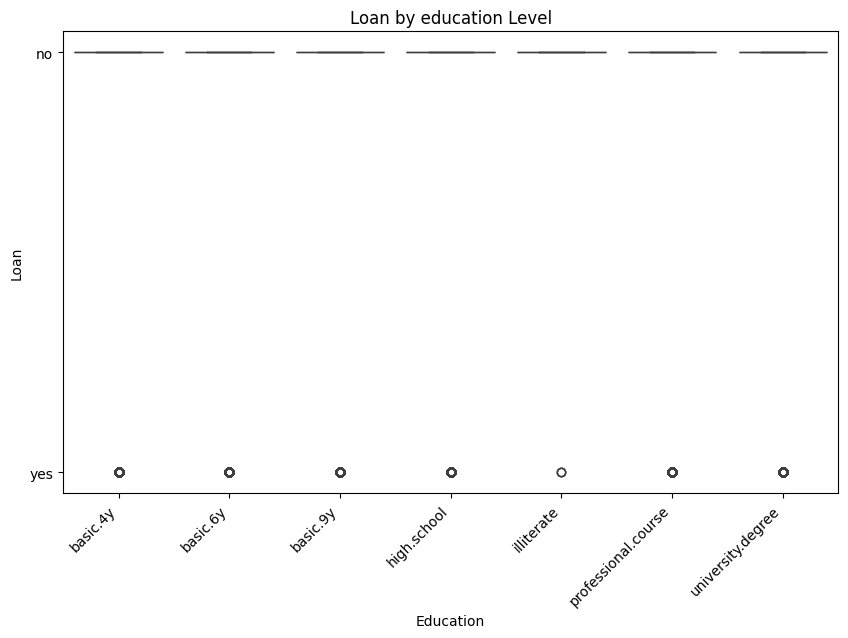

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='education', y='loan', data=data_cl)
plt.title('Loan by education Level')
plt.xlabel('Education')
plt.ylabel('Loan')
plt.xticks(rotation=45, ha='right')
plt.show()
plt.savefig('education_loan.png')


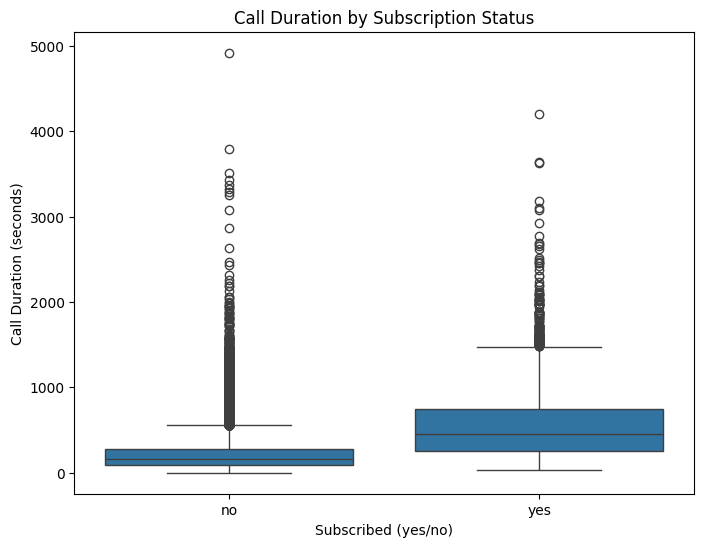

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='duration', data=data_cl)
plt.title('Call Duration by Subscription Status')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Call Duration (seconds)')
plt.show()
plt.savefig('subscription.png')


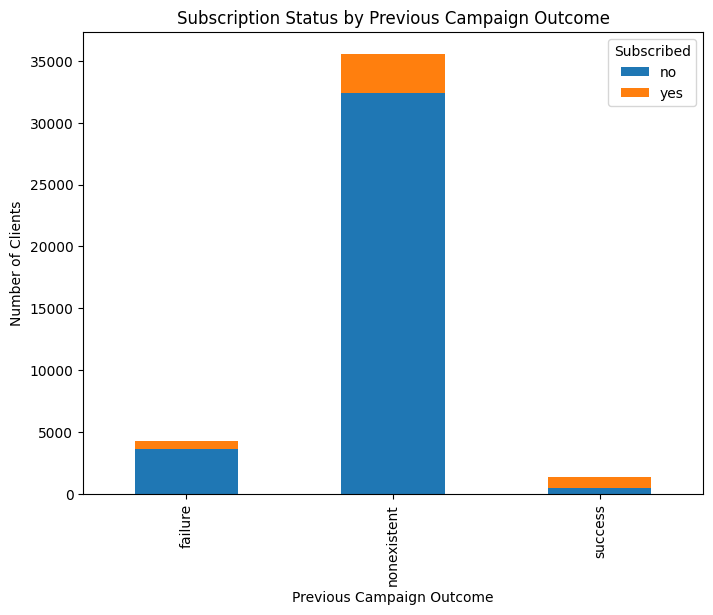

<Figure size 640x480 with 0 Axes>

In [ ]:
poutcome_by_subscription = pd.crosstab(data_cl['poutcome'], data_cl['y'])
poutcome_by_subscription.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Subscription Status by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Number of Clients')
plt.legend(title='Subscribed')
plt.show()
plt.savefig('subscription_status_previous_campaign.png')
